# Pandas Data Loading & Data Preparation Essentials
Lets Look into reading data from multiple sources and core DataFrame operations.

In [1]:

import pandas as pd
import numpy as np


## Creating Sample Dataset

In [2]:

data = {
    "Name": ["Amit", "Neha", "Rahul", "Priya", None],
    "Age": [25, 30, 28, None, 35],
    "Salary": [50000, 60000, None, 55000, 65000],
    "Department": ["IT", "HR", "IT", "Finance", "HR"]
}

df = pd.DataFrame(data)
df

,Name,Age,Salary,Department
0,Amit,25.0,50000.0,IT
1,Neha,30.0,60000.0,HR
2,Rahul,28.0,NaN,IT
3,Priya,NaN,55000.0,Finance
4,None,35.0,65000.0,HR


## Save dataset to different formats

In [3]:

df.to_csv("sample.csv", index=False)
df.to_excel("sample.xlsx", index=False)
df.to_json("sample.json")


## Read from CSV, Excel, JSON

In [4]:

df_csv = pd.read_csv("sample.csv")
df_excel = pd.read_excel("sample.xlsx")
df_json = pd.read_json("sample.json")


## Basic Inspection Methods

In [33]:
df_excel.head()

,Name,Age,Salary,Department
0,Amit,25.0,50000.0,IT
1,Neha,30.0,60000.0,HR
2,Rahul,28.0,NaN,IT
3,Priya,NaN,55000.0,Finance
4,NaN,35.0,65000.0,HR


In [34]:
df_json.head()

,Name,Age,Salary,Department
0,Amit,25.0,50000.0,IT
1,Neha,30.0,60000.0,HR
2,Rahul,28.0,NaN,IT
3,Priya,NaN,55000.0,Finance
4,None,35.0,65000.0,HR


In [ ]:
df_csv.head()

,Name,Age,Salary,Department
0,Amit,25.0,50000.0,IT
1,Neha,30.0,60000.0,HR
2,Rahul,28.0,NaN,IT
3,Priya,NaN,55000.0,Finance
4,NaN,35.0,65000.0,HR


In [8]:
df_csv.tail(2)

,Name,Age,Salary,Department
3,Priya,NaN,55000.0,Finance
4,NaN,35.0,65000.0,HR


In [9]:
df_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        4 non-null      object 
 1   Age         4 non-null      float64
 2   Salary      4 non-null      float64
 3   Department  5 non-null      object 
dtypes: float64(2), object(2)
memory usage: 292.0+ bytes


In [10]:
df_csv.describe()

,Age,Salary
count,4.000000,4.000000
mean,29.500000,57500.000000
std,4.203173,6454.972244
min,25.000000,50000.000000
25%,27.250000,53750.000000
50%,29.000000,57500.000000
75%,31.250000,61250.000000
max,35.000000,65000.000000


In [11]:
df_csv.shape


(5, 4)

## Handling Missing Values

In [12]:

df_csv.isnull().sum()


Name          1
Age           1
Salary        1
Department    0
dtype: int64

In [13]:
df_csv.dropna()

,Name,Age,Salary,Department
0,Amit,25.0,50000.0,IT
1,Neha,30.0,60000.0,HR


In [14]:
df_csv.fillna({"Age": df_csv["Age"].mean(), "Salary": df_csv["Salary"].mean()})

,Name,Age,Salary,Department
0,Amit,25.0,50000.0,IT
1,Neha,30.0,60000.0,HR
2,Rahul,28.0,57500.0,IT
3,Priya,29.5,55000.0,Finance
4,NaN,35.0,65000.0,HR


## Series vs DataFrame

In [15]:

# Series
ages = df_csv["Age"]
type(ages)


pandas.core.series.Series

In [16]:
# DataFrame
age_df = df_csv[["Age"]]
type(age_df)

pandas.core.frame.DataFrame

## Index Operations

In [17]:

df_csv.index
df_csv.index.name = "Employee_ID"
df_csv


,Name,Age,Salary,Department
Employee_ID,,,,
0,Amit,25.0,50000.0,IT
1,Neha,30.0,60000.0,HR
2,Rahul,28.0,NaN,IT
3,Priya,NaN,55000.0,Finance
4,NaN,35.0,65000.0,HR


## Data Types

In [19]:

df_csv["Age"] = df_csv["Age"].astype("float")
df_csv.dtypes

Name           object
Age           float64
Salary        float64
Department     object
dtype: object

## loc and iloc

In [22]:
df_csv.loc[0, "Name"]

'Amit'

In [23]:
df_csv.iloc[1, 2]

60000.0

In [24]:
df_csv.loc[df_csv["Department"] == "IT"]


,Name,Age,Salary,Department
Employee_ID,,,,
0,Amit,25.0,50000.0,IT
2,Rahul,28.0,NaN,IT


## Clipboard Example

In [ ]:

# Copy any table and run:
# df_clip = pd.read_clipboard()


In [32]:
df_clip = pd.read_clipboard()
df_clip

,"df_csv.loc[df_csv[""Department""]",==,"""IT""]"


In [35]:
df_csv.groupby("Department")["Salary"].mean()

Department
Finance    55000.0
HR         62500.0
IT         50000.0
Name: Salary, dtype: float64

<Axes: title={'center': 'Average Salary by Department'}, xlabel='Department'>

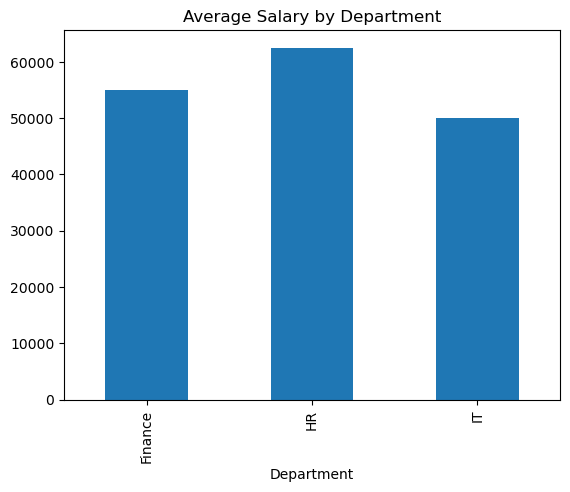

In [36]:
df_csv.groupby("Department")["Salary"].mean().plot(kind='bar', title='Average Salary by Department')

In [37]:
import sqlite3

In [47]:
conn = sqlite3.connect(
    r"C:\Users\NewUser\Downloads\Chinook_Sqlite.sqlite"
)

In [48]:
conn

In [49]:
pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

,name
0,Album
1,Artist
2,Customer
3,Employee
4,Genre
5,Invoice
6,InvoiceLine
7,MediaType
8,Playlist
9,PlaylistTrack


In [51]:
df_sql = pd.read_sql(
    "SELECT * FROM customer",
    conn
)
df_sql.head()

,CustomerId,FirstName,LastName,Company,Address,City,State,Country,PostalCode,Phone,Fax,Email,SupportRepId
0,1,Luís,Gonçalves,Embraer - Empresa Brasileira de Aeronáutica S.A.,"Av. Brigadeiro Faria Lima, 2170",São José dos Campos,SP,Brazil,12227-000,+55 (12) 3923-5555,+55 (12) 3923-5566,luisg@embraer.com.br,3
1,2,Leonie,Köhler,None,Theodor-Heuss-Straße 34,Stuttgart,None,Germany,70174,+49 0711 2842222,None,leonekohler@surfeu.de,5
2,3,François,Tremblay,None,1498 rue Bélanger,Montréal,QC,Canada,H2G 1A7,+1 (514) 721-4711,None,ftremblay@gmail.com,3
3,4,Bjørn,Hansen,None,Ullevålsveien 14,Oslo,None,Norway,0171,+47 22 44 22 22,None,bjorn.hansen@yahoo.no,4
4,5,František,Wichterlová,JetBrains s.r.o.,Klanova 9/506,Prague,None,Czech Republic,14700,+420 2 4172 5555,+420 2 4172 5555,frantisekw@jetbrains.com,4


In [52]:
df_sql.columns

Index(['CustomerId', 'FirstName', 'LastName', 'Company', 'Address', 'City',
       'State', 'Country', 'PostalCode', 'Phone', 'Fax', 'Email',
       'SupportRepId'],
      dtype='object')

In [53]:
df_sql.describe()

,CustomerId,SupportRepId
count,59.000000,59.000000
mean,30.000000,3.949153
std,17.175564,0.818403
min,1.000000,3.000000
25%,15.500000,3.000000
50%,30.000000,4.000000
75%,44.500000,5.000000
max,59.000000,5.000000


In [54]:
df_sql.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   CustomerId    59 non-null     int64 
 1   FirstName     59 non-null     object
 2   LastName      59 non-null     object
 3   Company       10 non-null     object
 4   Address       59 non-null     object
 5   City          59 non-null     object
 6   State         30 non-null     object
 7   Country       59 non-null     object
 8   PostalCode    55 non-null     object
 9   Phone         58 non-null     object
 10  Fax           12 non-null     object
 11  Email         59 non-null     object
 12  SupportRepId  59 non-null     int64 
dtypes: int64(2), object(11)
memory usage: 6.1+ KB


<Axes: title={'center': 'Average Customer by Country'}, xlabel='Country'>

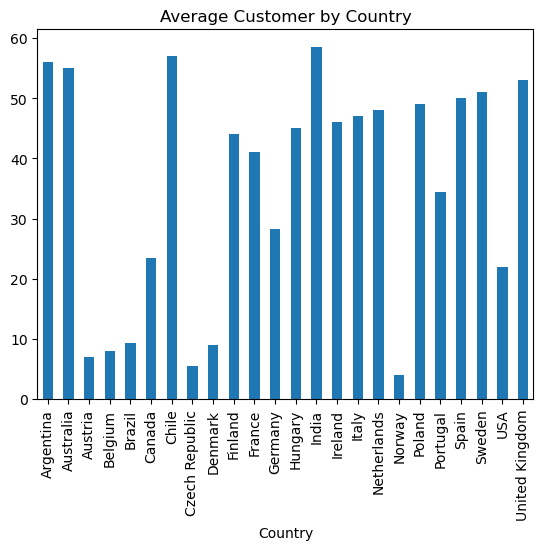

In [57]:
df_sql.groupby("Country")["CustomerId"].mean().plot(kind='bar', title='Average Customer by Country')